In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import learning_curve, validation_curve

In [2]:
df = pd.read_csv('E:/projects data analysis/customer churn/cust_data.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0) ## Replacing the blank with zeros
df['TotalCharges'] = df['TotalCharges'].astype('float')  

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.duplicated().sum()

0

In [9]:
df['customerID'].duplicated().sum()  # Checking duplicated on the basis of Unique value

0

In [10]:
# In this function we have conerted 0 and 1 t0 No and Yes to make it easiser
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [11]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


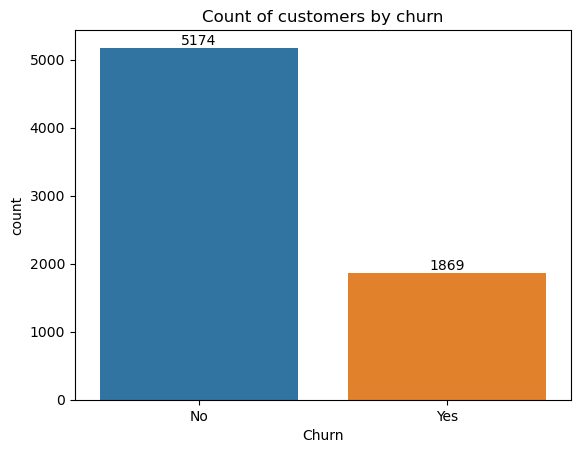

In [12]:
#Analysis --> 1. Why customers had churn out and why ?
#How many customers had churn or not. to have a look on this we will use the countplot

ax = sns.countplot(x = df['Churn'], data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by churn")
plt.show()

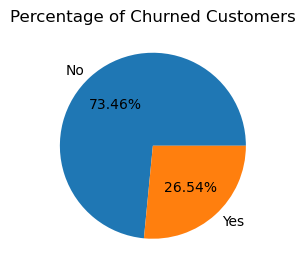

In [13]:
# If we want to see in terms of %(percentage)
plt.figure(figsize = (3, 4))
gb = df.groupby('Churn').agg({'Churn' : 'count'})
plt.pie(gb['Churn'], labels = gb.index, autopct = '%1.2f%%')
plt.title('Percentage of Churned Customers')
plt.show()

From the above graph we can say that only 26.54% customers have churned out. Now lets explore the reasons behind it.


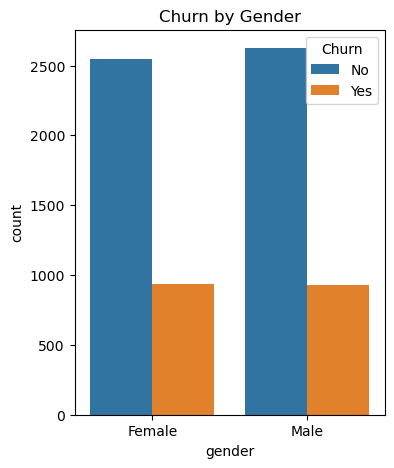

In [14]:
# First we will explore on the basis of the gender !
plt.figure(figsize = (4, 5))
sns.countplot(x = 'gender', data = df, hue = 'Churn')
plt.title('Churn by Gender')
plt.show()

In [15]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

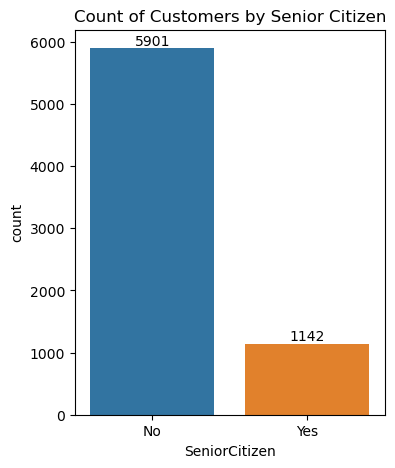

In [16]:
plt.figure(figsize = (4,5))
ax = sns.countplot(x = 'SeniorCitizen', data = df)
ax.bar_label(ax.containers[0])
plt.title('Count of Customers by Senior Citizen')
plt.show()

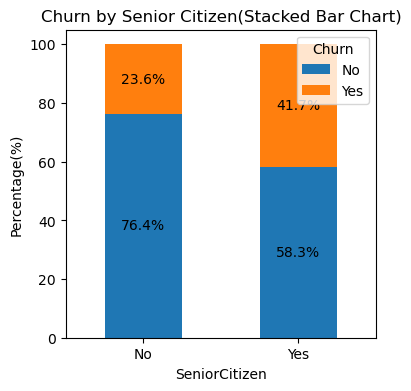

In [17]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize = True).unstack() * 100

#plot 
fig, ax = plt.subplots(figsize = (4, 4))

#plot the bars
total_counts.plot(kind = 'bar', stacked = True, ax = ax)

#Add Percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height :.1f}%', ha = 'center', va = 'center')
    
plt.title('Churn by Senior Citizen(Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage(%)')
plt.xticks(rotation = 0)
plt.legend(title = 'Churn', loc = 'upper right')
    
plt.show()

comparatively a greater % of people in senior citizen category have churned

<Axes: xlabel='tenure', ylabel='Count'>

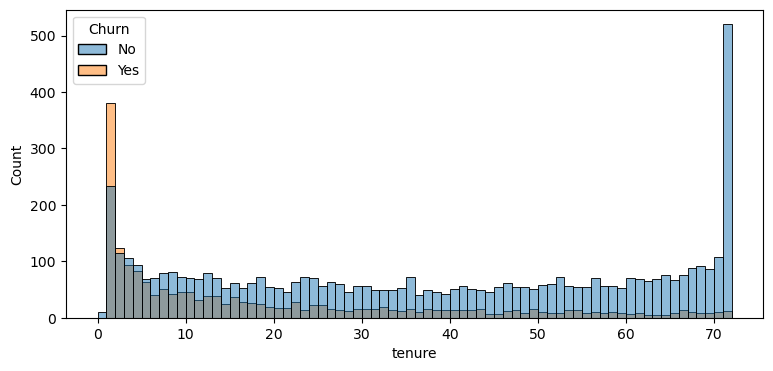

In [18]:
# checking on the basis of tenuure !
fig = plt.subplots(figsize = (9, 4))
sns.histplot(x = 'tenure', data = df, bins = 72, hue = 'Churn')

People who have used our services for a long time have stayed and people who have used our services for one or two months have Churned

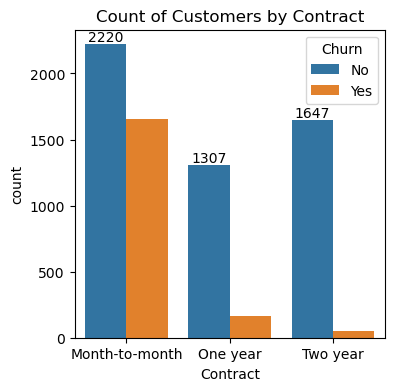

In [19]:
#Now on the basis of contract
plt.figure(figsize = (4,4))
ax = sns.countplot(x = 'Contract', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title('Count of Customers by Contract')
plt.show()

People who have month to month contract are likely to churn as compare to those who have one year or two year contract.

In [20]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

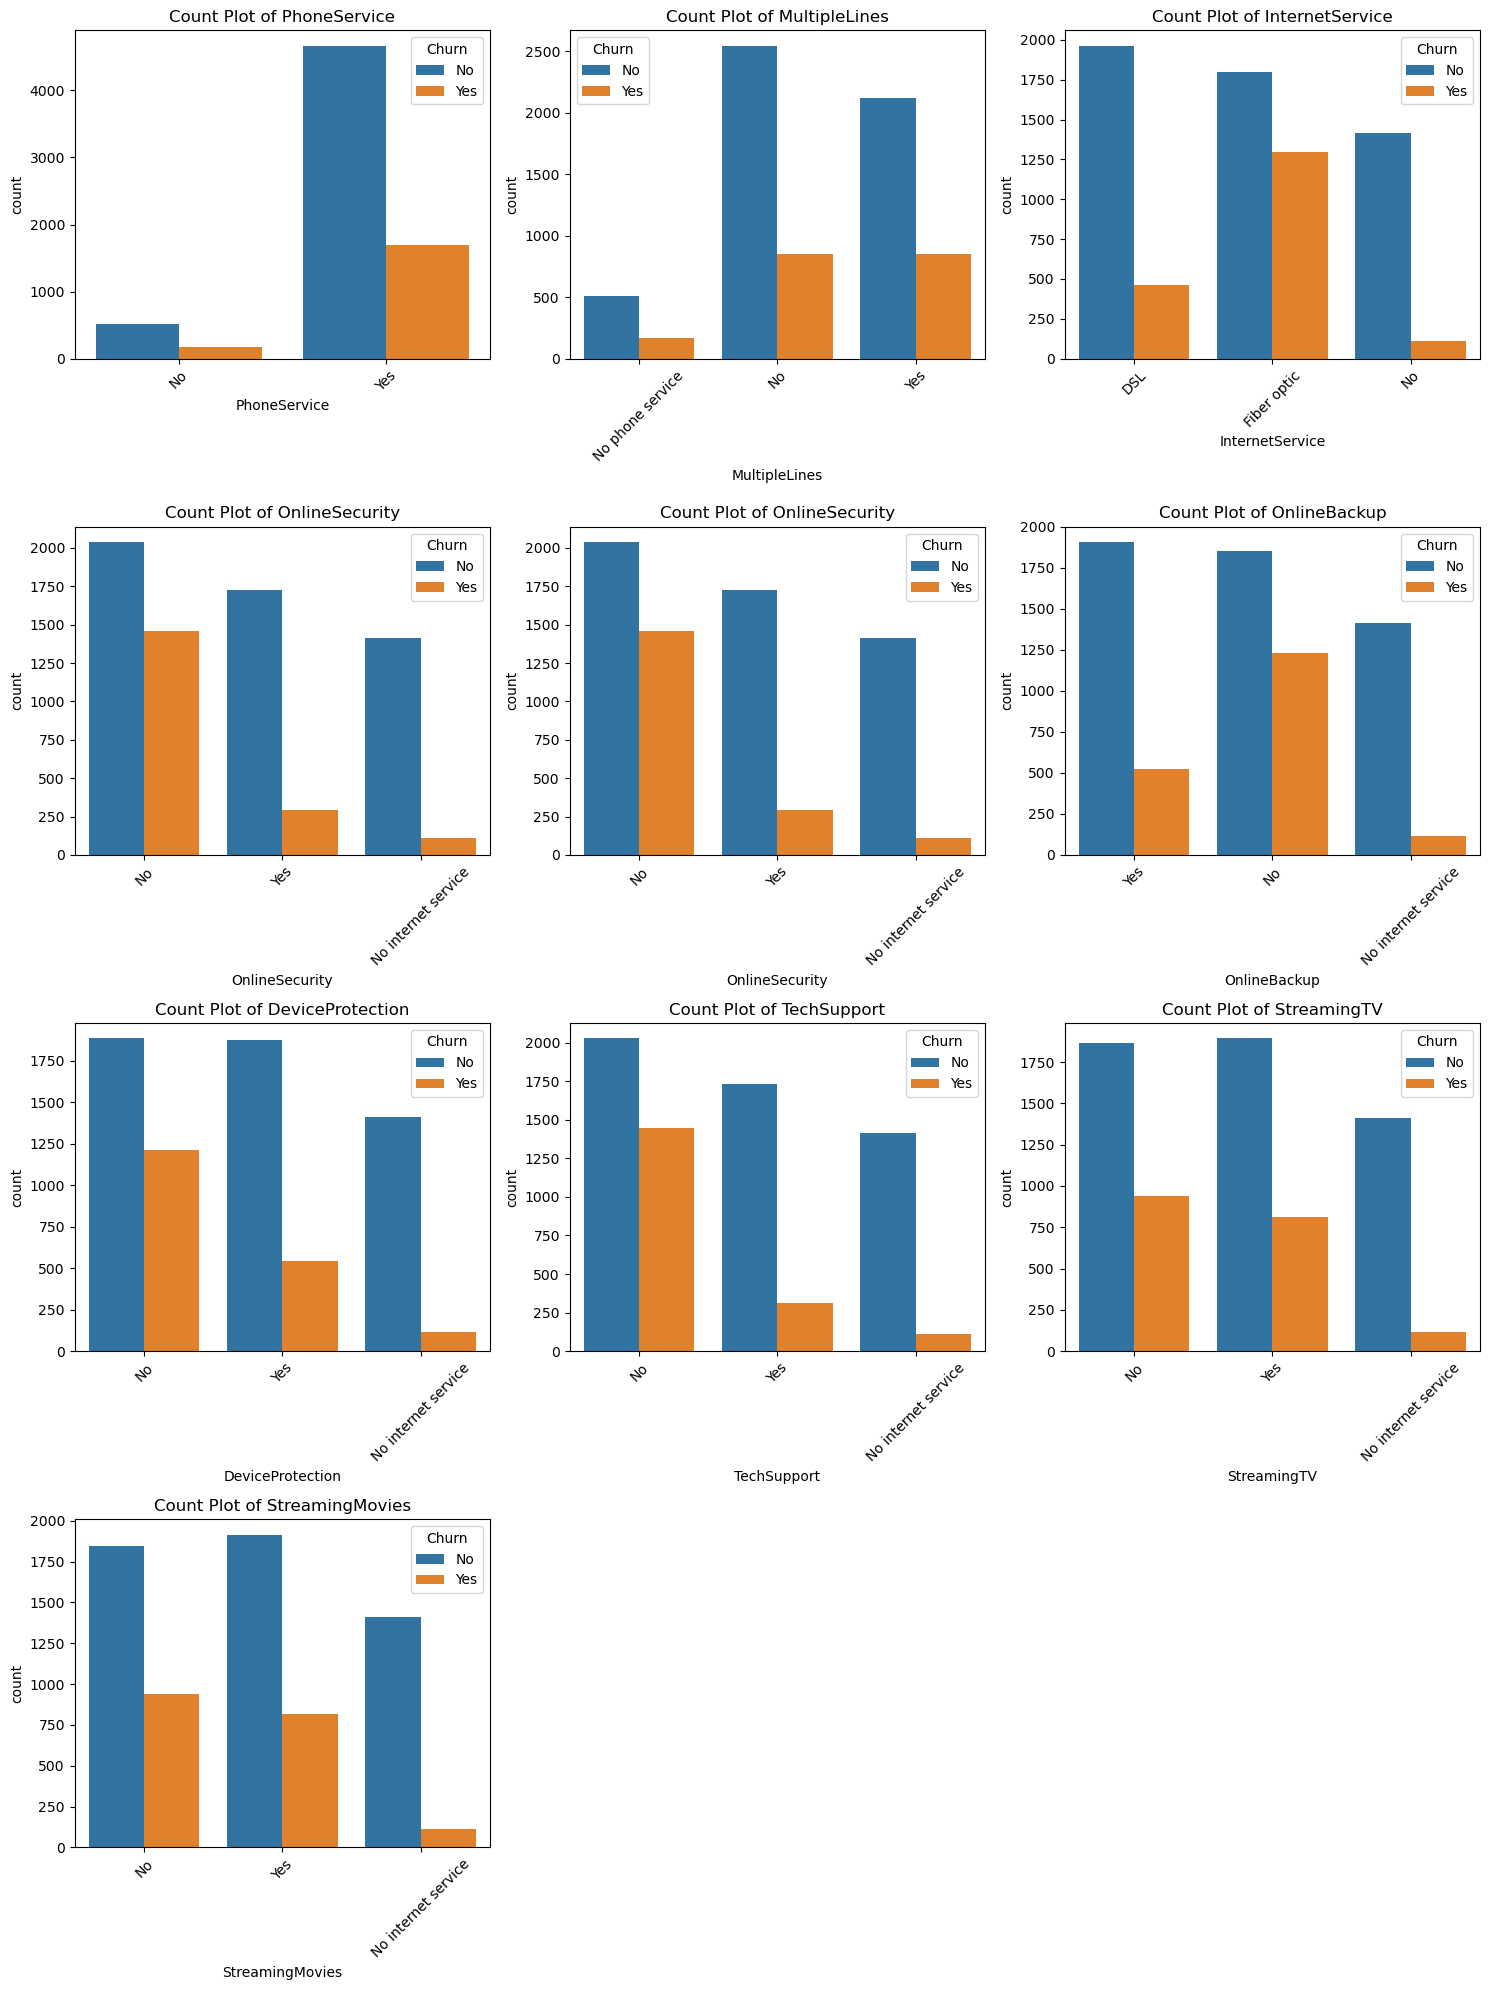

In [21]:


# Assuming your dataframe is called df.
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

num_cols = len(columns)
num_rows = (num_cols + 2) // 3  # Calculate rows to fit columns in a 3-column grid

fig, axes = plt.subplots(num_rows, min(num_cols, 3), figsize=(15, 5 * num_rows))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = 'Churn')
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels if needed

# Remove any unused subplots
for j in range(num_cols, num_rows * 3):
    fig.delaxes(axes[j])
plt.savefig('churn_analysis.jpg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

visualization displays count plots for various categorical features, segmented by customer churn (yes/no).  Phone service and internet service show a clear disparity in churn rates, with customers having phone service and fiber optic internet more likely to churn.  Multiple lines and online security also exhibit some influence on churn, though less pronounced.  Streaming services and device protection show relatively similar churn patterns across categories, suggesting a weaker correlation with chur

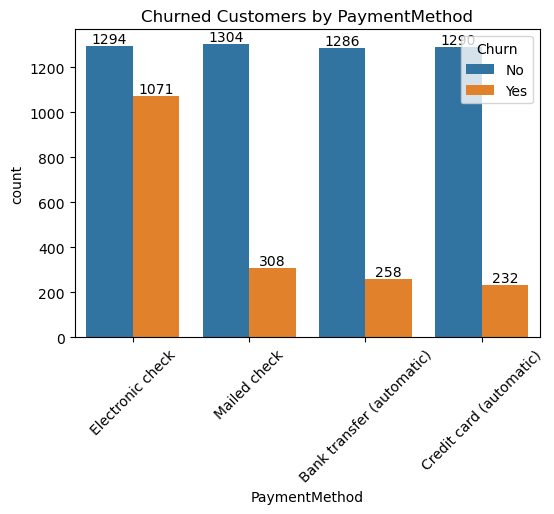

In [22]:
#Now on the basis of PaymentMethod
plt.figure(figsize = (6,4))
ax = sns.countplot(x = 'PaymentMethod', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation= 45)
plt.title('Churned Customers by PaymentMethod')
plt.show()

Customer is likely to churn when he is using electronic cjeck as a payment method

C:\Users\Raheem Khan\AppData\Local\Temp\ipykernel_10288\1436806122.py:12: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df[numerical_cols].corr()


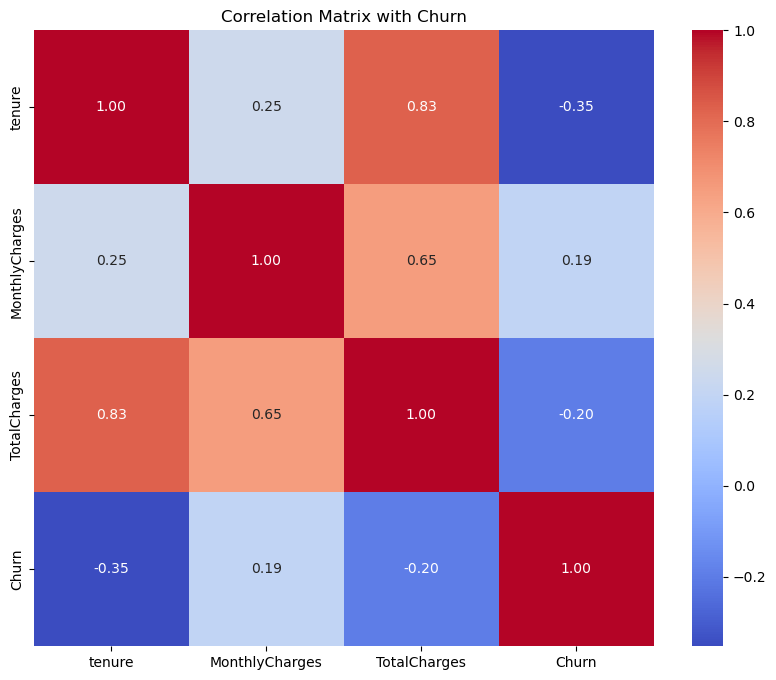

In [23]:
# Convert 'TotalCharges' to numeric, handling errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # remove rows with NaN TotalCharges

# Convert 'Churn' to numerical (1 for Yes, 0 for No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select numerical columns for correlation
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'SeniorCitizen', 'Partner','Dependents']

# Create the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.savefig('churn_analysis1.jpg', dpi=300, bbox_inches='tight')
plt.title('Correlation Matrix with Churn')
plt.show()

In [24]:
# Print the correlation table
print("Correlation Table:\n")
print(correlation_matrix.to_markdown(numalign="left", stralign="left"))  # Using to_markdown for better formatting


Correlation Table:

|                | tenure    | MonthlyCharges   | TotalCharges   | Churn     |
|:---------------|:----------|:-----------------|:---------------|:----------|
| tenure         | 1         | 0.2479           | 0.826178       | -0.352229 |
| MonthlyCharges | 0.2479    | 1                | 0.651174       | 0.193356  |
| TotalCharges   | 0.826178  | 0.651174         | 1              | -0.198324 |
| Churn          | -0.352229 | 0.193356         | -0.198324      | 1         |


In [25]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [26]:
X = df.drop(columns = ['Churn'])
y = df['Churn']

In [27]:
# Drop customerID as it's not a predictive feature
X = X.drop('customerID', axis=1)

In [28]:
X.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.15, random_state=2)

In [30]:
# Identify numerical and categorical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [31]:
# Identify numerical and categorical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [32]:
nominal_transformer = OneHotEncoder(handle_unknown='ignore', drop = 'first')  # handle_unknown='ignore' added
numerical_transformer = MinMaxScaler()

In [33]:
# Preprocessing steps for numerical columns
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])



In [34]:
# Preprocessing steps for categorical columns
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [35]:
# Column Transformer to apply different preprocessing to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformer, numerical_cols),
        ('categorical', categorical_transformer, categorical_cols)  # Apply OneHotEncoder to all categorical columns
    ],
    remainder='passthrough',  # Keep the remaining columns as is
    verbose=True
)

In [36]:
# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])


In [37]:
# Train the model using the pipeline
pipeline.fit(X_train, y_train)

[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])],
                                   verbose=True)),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

In [38]:
# Make predictions on the test set
y_pred = pipeline.predict(X_test)


In [39]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[704  81]
 [127 145]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       785
           1       0.64      0.53      0.58       272

    accuracy                           0.80      1057
   macro avg       0.74      0.71      0.73      1057
weighted avg       0.79      0.80      0.80      1057



In [40]:
print(accuracy_score(y_test, y_pred))

0.8032166508987701


In [41]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

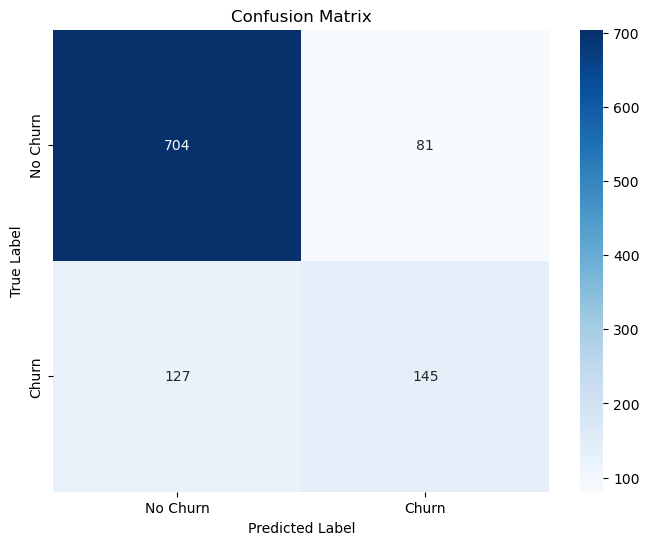

In [42]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

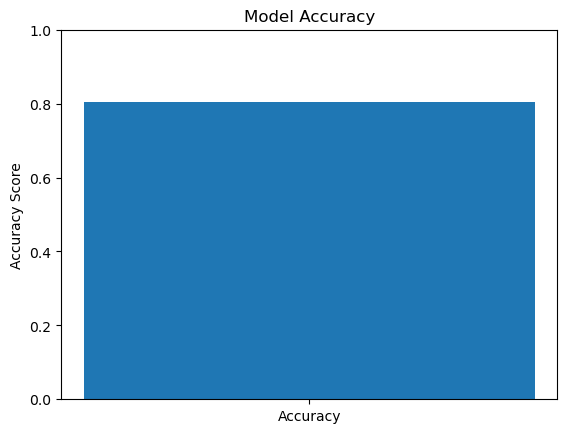

In [43]:
# Visualize the accuracy
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)  # Set the y-axis limit between 0 and 1
plt.title('Model Accuracy')
plt.ylabel('Accuracy Score')
plt.show()

[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.0s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.0s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.0s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.0s
[Colum

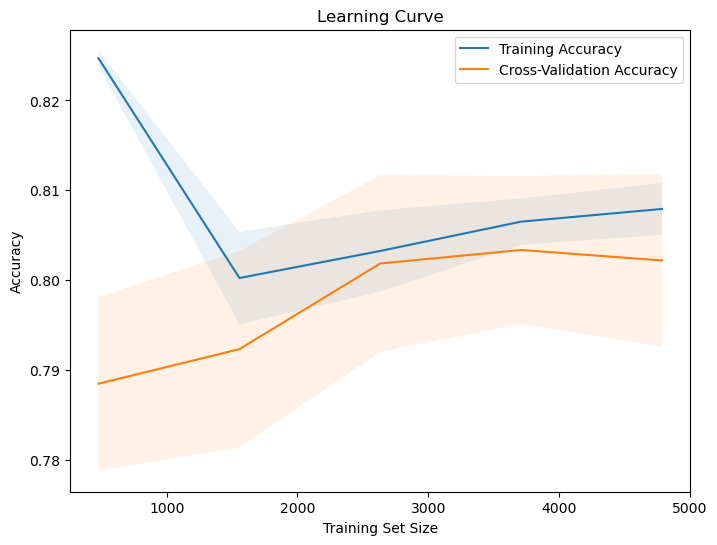

In [44]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5))
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, test_mean, label='Cross-Validation Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

The above greaph helps assess how a model's performance varies with changes in the training set size, allowing us to diagnose issues like underfitting or overfitting due to insufficient data.  validation_curve, on the other hand, evaluates the impact of a specific model parameter (e.g., regularization strength) on performance, aiding in hyperparameter tuning to find the optimal balance between bias and variance.  Both functions employ cross-validation to provide robust estimates of model performance, generating the data necessary to plot informative graphs.  These visualizations are crucial for understanding a model's behavior and making informed decisions about model improvement.

[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.0s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.1s
[Colum

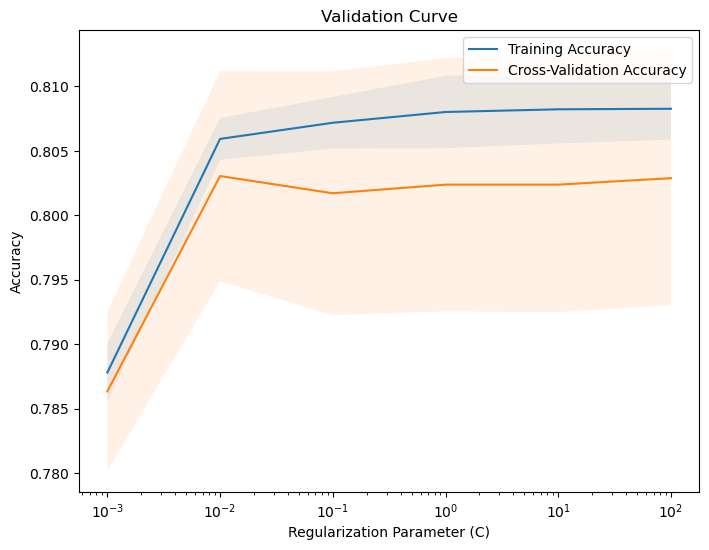

<Figure size 640x480 with 0 Axes>

In [48]:
# Validation Curve
param_range = [0.001, 0.01, 0.1, 1, 10, 100]  # Example parameter range for C in Logistic Regression
train_scores, test_scores = validation_curve(
    pipeline, X_train, y_train, param_name='classifier__C', param_range=param_range, cv=5, scoring='accuracy')
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.semilogx(param_range, train_mean, label='Training Accuracy')
plt.semilogx(param_range, test_mean, label='Cross-Validation Accuracy')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('Accuracy')
plt.title('Validation Curve')

plt.legend()
plt.show()
plt.savefig('churn_analysis3.png', dpi=300, bbox_inches='tight')

The selected code generates a validation curve, which helps in understanding how the model's performance is affected by changes in a hyperparameter.  Specifically, it shows how the training and cross-validation accuracy change as the regularization parameter 'C' of the Logistic Regression model varies.  The plot helps identify the optimal 'C' value that balances bias and variance, avoiding overfitting or underfitting.  A smaller 'C' implies stronger regularization.